### Cell 1 — Mount + imports + paths

In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path("/content/drive/MyDrive/rectified_flow_ct2dose")
SPLIT_DIR = BASE_DIR / "data" / "splits"
ANALYSIS_DIR = BASE_DIR / "analysis"

OUT_DIR = ANALYSIS_DIR / "ct2dose_phase4_case_routing_analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)

VAL_MANIFEST = SPLIT_DIR / "train_pairs_3d_val_phase3_500.json"

# 这里使用你之前已经跑好的三模型 casewise metrics
CASEWISE_METRICS_CSV = (
    ANALYSIS_DIR
    / "ct2dose_phase4_targeted_evaluation"
    / "ct2dose_targeted_casewise_metrics_evalT0p1.csv"
)

print("VAL_MANIFEST exists:", VAL_MANIFEST.exists())
print("CASEWISE_METRICS_CSV exists:", CASEWISE_METRICS_CSV.exists())

Mounted at /content/drive
VAL_MANIFEST exists: True
CASEWISE_METRICS_CSV exists: True


### Cell 2 — Optional title

In [2]:
from IPython.display import Markdown, display

display(Markdown(r"""
# CT-to-Dose Phase 4: Case Routing Analysis
## Goal
- keep the current three meaningful reference models:
  - tuned
  - mixed T=0.10
  - mixed T=0.15
- analyze model-specific best/worst cases
- test whether simple CT-only routing can improve case selection
"""))


# CT-to-Dose Phase 4: Case Routing Analysis
## Goal
- keep the current three meaningful reference models:
  - tuned
  - mixed T=0.10
  - mixed T=0.15
- analyze model-specific best/worst cases
- test whether simple CT-only routing can improve case selection


### Cell 3 — Load the existing casewise comparison table

In [3]:
comparison_df = pd.read_csv(CASEWISE_METRICS_CSV)

keep_models = ["tuned", "mixed_T010_a030_mw3", "mixed_T015_a030_mw3"]
comparison_df = comparison_df[comparison_df["model"].isin(keep_models)].copy()

print("Rows:", len(comparison_df))
print("Models:", comparison_df["model"].unique())
display(comparison_df.head())

Rows: 1500
Models: ['tuned' 'mixed_T010_a030_mw3' 'mixed_T015_a030_mw3']


,model,sample_idx,bone_in_beam_candidate,bone_fraction_in_relevant_band,max_hu_in_relevant_band,beam_slice_idx,beam_peak_y,beam_peak_x,overall_mse,overall_mae,...,high_rel_err_pct,outside_mse,outside_mae,outside_max_abs_error,outside_p95_abs_error,peak_core_mae,peak_shoulder_mae,threshold_used,num_high_voxels,num_outside_voxels
0,tuned,0,True,0.184211,830.923096,16,16,0,0.000015,0.002473,...,2.674173,0.000009,0.002039,0.033033,0.005827,0.116184,0.040654,0.1,4792,27976
1,mixed_T010_a030_mw3,0,True,0.184211,830.923096,16,16,0,0.000017,0.002729,...,3.067758,0.000010,0.002213,0.030378,0.006510,0.016533,0.026898,0.1,4792,27976
2,mixed_T015_a030_mw3,0,True,0.184211,830.923096,16,16,0,0.000023,0.003124,...,4.279956,0.000010,0.002287,0.029699,0.006290,0.134365,0.034779,0.1,4792,27976
3,tuned,1,False,0.000000,48.529053,16,16,0,0.000024,0.002947,...,2.663383,0.000019,0.002665,0.048242,0.009109,0.119688,0.050971,0.1,4218,28550
4,mixed_T010_a030_mw3,1,False,0.000000,48.529053,16,16,0,0.000028,0.003210,...,2.468965,0.000024,0.003019,0.050761,0.010374,0.032907,0.030689,0.1,4218,28550


### Cell 4 — Dataset helper + CT normalization inversion

In [8]:
DOSE_SCALE = 1000.0

def denormalize_ct(x_norm):
    return x_norm * (1500.0 + 1024.0) - 1024.0

class CubePair3DDataset:
    def __init__(self, manifest_path, dose_scale=1000.0):
        with open(manifest_path, "r", encoding="utf-8") as f:
            self.records = json.load(f)
        self.dose_scale = dose_scale

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]

        x0 = np.load(rec["input_path"]).astype(np.float32)
        x1 = np.load(rec["output_path"]).astype(np.float32)

        # x0 was normalized in training as:
        # x0 = (clip(x0,-1024,1500) + 1024) / (1500+1024)
        x0 = np.clip(x0, -1024.0, 1500.0)
        x0 = (x0 + 1024.0) / (1500.0 + 1024.0)

        x1 = (x1 * self.dose_scale).astype(np.float32)
        return x0, x1

val_dataset_3d = CubePair3DDataset(VAL_MANIFEST, dose_scale=DOSE_SCALE)
print("Validation samples:", len(val_dataset_3d))

Validation samples: 500


### Cell 5 — CT-only feature extraction for routing

In [9]:
def compute_gradient_magnitude_3d(vol):
    gz, gy, gx = np.gradient(vol)
    grad = np.sqrt(gz**2 + gy**2 + gx**2)
    return grad

def compute_ct_only_routing_features(ct_vol_norm):
    """
    输入:
        ct_vol_norm: [D,H,W], normalized CT
    输出:
        一组只依赖 CT 的 routing 特征
    """
    ct_hu = denormalize_ct(ct_vol_norm)

    D, H, W = ct_hu.shape

    # central corridor 假设 beam 大致穿过中间区域
    zc = D // 2
    yc = H // 2

    z_half = 2
    y_half = 3

    z0 = max(0, zc - z_half)
    z1 = min(D, zc + z_half + 1)

    y0 = max(0, yc - y_half)
    y1 = min(H, yc + y_half + 1)

    corridor = ct_hu[z0:z1, y0:y1, :]   # [zband, yband, x]

    grad_mag = compute_gradient_magnitude_3d(corridor)

    return {
        "ct_global_mean": float(np.mean(ct_hu)),
        "ct_global_std": float(np.std(ct_hu)),

        "corridor_hu_mean": float(np.mean(corridor)),
        "corridor_hu_std": float(np.std(corridor)),

        "corridor_high_hu_frac": float(np.mean(corridor >= 300.0)),
        "corridor_very_high_hu_frac": float(np.mean(corridor >= 700.0)),
        "corridor_low_hu_frac": float(np.mean(corridor <= -500.0)),

        "corridor_grad_mean": float(np.mean(grad_mag)),
        "corridor_grad_p95": float(np.percentile(grad_mag, 95)),
        "corridor_grad_max": float(np.max(grad_mag)),
    }

### Cell 6 — Build per-case CT-only feature table

In [10]:
feature_rows = []

for idx in range(len(val_dataset_3d)):
    ct_vol_norm, gt_vol = val_dataset_3d[idx]

    feats = compute_ct_only_routing_features(ct_vol_norm)

    feature_rows.append({
        "sample_idx": idx,
        **feats
    })

ct_feature_df = pd.DataFrame(feature_rows)

ct_feature_csv = OUT_DIR / "ct2dose_case_routing_ct_only_features.csv"
ct_feature_df.to_csv(ct_feature_csv, index=False)

print("Saved:", ct_feature_csv)
display(ct_feature_df.head())

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_case_routing_analysis/ct2dose_case_routing_ct_only_features.csv


,sample_idx,ct_global_mean,ct_global_std,corridor_hu_mean,corridor_hu_std,corridor_high_hu_frac,corridor_very_high_hu_frac,corridor_low_hu_frac,corridor_grad_mean,corridor_grad_p95,corridor_grad_max
0,0,-31.815182,412.025940,158.658554,230.781235,0.199107,0.038393,0.000893,168.677139,600.988647,1282.359863
1,1,-273.297333,607.517883,-78.870163,492.399261,0.133929,0.075000,0.200893,100.988579,473.230743,580.000610
2,2,-342.263367,569.002319,64.210602,607.292480,0.238393,0.150893,0.168750,423.409180,1084.093994,2351.531006
3,3,60.876251,366.860229,150.029755,402.223480,0.300893,0.091964,0.065179,258.608307,689.617493,1148.643677
4,4,-130.254517,460.225006,-120.566223,431.585846,0.098214,0.000893,0.206250,147.616837,519.878723,1037.535767


### Cell 7 — Build wide per-case metric table

In [11]:
# 只保留 comparison_df 里实际存在的公共信息列
base_case_info_cols = [
    "sample_idx",
    "bone_in_beam_candidate",
    "bone_fraction_in_relevant_band",
    "max_hu_in_relevant_band",
]

available_case_info_cols = [c for c in base_case_info_cols if c in comparison_df.columns]
missing_case_info_cols = [c for c in base_case_info_cols if c not in comparison_df.columns]

print("Available case info cols:", available_case_info_cols)
print("Missing case info cols:", missing_case_info_cols)

case_info_df = (
    comparison_df[comparison_df["model"] == "tuned"][available_case_info_cols]
    .copy()
    .drop_duplicates(subset=["sample_idx"])
    .reset_index(drop=True)
)

metric_cols = [
    "overall_mae",
    "weighted_mse",
    "high_mae",
    "outside_mae",
    "outside_max_abs_error",
    "peak_core_mae",
    "peak_shoulder_mae",
]

wide_df = case_info_df.merge(ct_feature_df, on="sample_idx", how="left")

for metric in metric_cols:
    pivot = comparison_df.pivot(index="sample_idx", columns="model", values=metric).reset_index()
    pivot = pivot.rename(columns={
        "tuned": f"{metric}_tuned",
        "mixed_T010_a030_mw3": f"{metric}_t010",
        "mixed_T015_a030_mw3": f"{metric}_t015",
    })
    wide_df = wide_df.merge(pivot, on="sample_idx", how="left")

wide_csv = OUT_DIR / "ct2dose_case_routing_wide_case_table.csv"
wide_df.to_csv(wide_csv, index=False)

print("Saved:", wide_csv)
display(wide_df.head())

Available case info cols: ['sample_idx', 'bone_in_beam_candidate', 'bone_fraction_in_relevant_band', 'max_hu_in_relevant_band']
Missing case info cols: []
Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_case_routing_analysis/ct2dose_case_routing_wide_case_table.csv


,sample_idx,bone_in_beam_candidate,bone_fraction_in_relevant_band,max_hu_in_relevant_band,ct_global_mean,ct_global_std,corridor_hu_mean,corridor_hu_std,corridor_high_hu_frac,corridor_very_high_hu_frac,...,outside_mae_tuned,outside_max_abs_error_t010,outside_max_abs_error_t015,outside_max_abs_error_tuned,peak_core_mae_t010,peak_core_mae_t015,peak_core_mae_tuned,peak_shoulder_mae_t010,peak_shoulder_mae_t015,peak_shoulder_mae_tuned
0,0,True,0.184211,830.923096,-31.815182,412.025940,158.658554,230.781235,0.199107,0.038393,...,0.002039,0.030378,0.029699,0.033033,0.016533,0.134365,0.116184,0.026898,0.034779,0.040654
1,1,False,0.000000,48.529053,-273.297333,607.517883,-78.870163,492.399261,0.133929,0.075000,...,0.002665,0.050761,0.051075,0.048242,0.032907,0.075141,0.119688,0.030689,0.026899,0.050971
2,2,True,0.117647,903.819946,-342.263367,569.002319,64.210602,607.292480,0.238393,0.150893,...,0.003040,0.034206,0.036064,0.057801,0.058735,0.002569,0.005584,0.012451,0.014012,0.010694
3,3,True,0.435897,746.846069,60.876251,366.860229,150.029755,402.223480,0.300893,0.091964,...,0.002290,0.033873,0.025950,0.029198,0.147713,0.120445,0.135589,0.072804,0.040796,0.051691
4,4,False,0.000000,90.889771,-130.254517,460.225006,-120.566223,431.585846,0.098214,0.000893,...,0.002395,0.023765,0.033295,0.024767,0.029119,0.010131,0.025972,0.021747,0.011315,0.013357


### Cell 8 — Model-specific best / typical / worst cases

In [12]:
model_specific_rows = []

for model_name in keep_models:
    sub = comparison_df[comparison_df["model"] == model_name].sort_values("weighted_mse").reset_index(drop=True)

    best_row = sub.iloc[0]
    typical_row = sub.iloc[len(sub) // 2]
    worst_row = sub.iloc[-1]

    for tag, row in [("best", best_row), ("typical", typical_row), ("worst", worst_row)]:
        model_specific_rows.append({
            "model": model_name,
            "case_tag": tag,
            "sample_idx": int(row["sample_idx"]),
            "weighted_mse": float(row["weighted_mse"]),
            "overall_mae": float(row["overall_mae"]),
            "high_mae": float(row["high_mae"]),
            "peak_core_mae": float(row["peak_core_mae"]),
            "peak_shoulder_mae": float(row["peak_shoulder_mae"]),
        })

model_specific_cases_df = pd.DataFrame(model_specific_rows)

model_specific_cases_csv = OUT_DIR / "ct2dose_case_routing_model_specific_best_typical_worst.csv"
model_specific_cases_df.to_csv(model_specific_cases_csv, index=False)

print("Saved:", model_specific_cases_csv)
display(model_specific_cases_df)

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_case_routing_analysis/ct2dose_case_routing_model_specific_best_typical_worst.csv


,model,case_tag,sample_idx,weighted_mse,overall_mae,high_mae,peak_core_mae,peak_shoulder_mae
0,tuned,best,496,0.000005,0.001551,0.002186,0.003423,0.003524
1,tuned,typical,491,0.000026,0.002507,0.004329,0.075612,0.021980
2,tuned,worst,221,0.000575,0.003337,0.010044,0.301265,0.138476
3,mixed_T010_a030_mw3,best,76,0.000006,0.001675,0.002649,0.008031,0.003726
4,mixed_T010_a030_mw3,typical,321,0.000027,0.002023,0.003251,0.074521,0.020445
5,mixed_T010_a030_mw3,worst,50,0.000467,0.006091,0.016237,0.139217,0.119438
6,mixed_T015_a030_mw3,best,378,0.000006,0.001477,0.002291,0.029074,0.006512
7,mixed_T015_a030_mw3,typical,325,0.000026,0.002655,0.004879,0.024192,0.011979
8,mixed_T015_a030_mw3,worst,50,0.000398,0.006779,0.018117,0.068969,0.098156


### Cell 9 — Oracle routing upper bound

In [13]:
oracle_rows = []

for metric in metric_cols:
    pivot = comparison_df.pivot(index="sample_idx", columns="model", values=metric)
    winner = pivot.idxmin(axis=1)

    selected_rows = []
    for sample_idx, chosen_model in winner.items():
        row = comparison_df[
            (comparison_df["sample_idx"] == sample_idx) &
            (comparison_df["model"] == chosen_model)
        ].iloc[0]
        selected_rows.append(row)

    selected_df = pd.DataFrame(selected_rows)

    oracle_rows.append({
        "routing_metric": metric,
        "overall_mae": float(selected_df["overall_mae"].mean()),
        "weighted_mse": float(selected_df["weighted_mse"].mean()),
        "high_mae": float(selected_df["high_mae"].mean()),
        "outside_mae": float(selected_df["outside_mae"].mean()),
        "outside_max_abs_error": float(selected_df["outside_max_abs_error"].mean()),
        "peak_core_mae": float(selected_df["peak_core_mae"].mean()),
        "peak_shoulder_mae": float(selected_df["peak_shoulder_mae"].mean()),
    })

oracle_summary_df = pd.DataFrame(oracle_rows)

oracle_csv = OUT_DIR / "ct2dose_case_routing_oracle_summary.csv"
oracle_summary_df.to_csv(oracle_csv, index=False)

print("Saved:", oracle_csv)
display(oracle_summary_df)

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_case_routing_analysis/ct2dose_case_routing_oracle_summary.csv


,routing_metric,overall_mae,weighted_mse,high_mae,outside_mae,outside_max_abs_error,peak_core_mae,peak_shoulder_mae
0,overall_mae,0.002499,0.000029,0.004175,0.002280,0.033340,0.035402,0.017607
1,weighted_mse,0.002558,0.000025,0.004126,0.002349,0.033697,0.026388,0.014035
2,high_mae,0.002558,0.000028,0.003973,0.002368,0.034117,0.033664,0.016007
3,outside_mae,0.002525,0.000034,0.004533,0.002263,0.033032,0.044170,0.020480
4,outside_max_abs_error,0.002674,0.000036,0.004767,0.002400,0.028868,0.046757,0.020888
5,peak_core_mae,0.002638,0.000027,0.004334,0.002414,0.033519,0.020136,0.015144
6,peak_shoulder_mae,0.002630,0.000026,0.004280,0.002409,0.034205,0.027951,0.013226


### Cell 10 — Define a simple CT-only routing rule

In [14]:
q25_std = wide_df["corridor_hu_std"].quantile(0.25)
q75_std = wide_df["corridor_hu_std"].quantile(0.75)

q25_high = wide_df["corridor_high_hu_frac"].quantile(0.25)
q75_high = wide_df["corridor_high_hu_frac"].quantile(0.75)

q25_grad = wide_df["corridor_grad_p95"].quantile(0.25)
q75_grad = wide_df["corridor_grad_p95"].quantile(0.75)

print("Quantiles:")
print("corridor_hu_std   q25 =", q25_std, " q75 =", q75_std)
print("corridor_high_hu_frac q25 =", q25_high, " q75 =", q75_high)
print("corridor_grad_p95 q25 =", q25_grad, " q75 =", q75_grad)

def route_case_ct_only(row):
    # hard / heterogeneous / bone-like proxy
    is_hard = (
        (row["corridor_hu_std"] >= q75_std) or
        (row["corridor_high_hu_frac"] >= q75_high) or
        (row["corridor_grad_p95"] >= q75_grad)
    )

    # easy / uniform proxy
    is_easy = (
        (row["corridor_hu_std"] <= q25_std) and
        (row["corridor_high_hu_frac"] <= q25_high) and
        (row["corridor_grad_p95"] <= q25_grad)
    )

    if is_hard:
        return "mixed_T010_a030_mw3"
    elif is_easy:
        return "tuned"
    else:
        return "mixed_T015_a030_mw3"

Quantiles:
corridor_hu_std   q25 = 357.4804153442383  q75 = 495.0528259277344
corridor_high_hu_frac q25 = 0.010714285714285714  q75 = 0.10446428571428572
corridor_grad_p95 q25 = 447.1187057495117  q75 = 693.332763671875


### Cell 11 — Apply routing rule

In [15]:
routing_df = wide_df.copy()
routing_df["routed_model"] = routing_df.apply(route_case_ct_only, axis=1)

routing_csv = OUT_DIR / "ct2dose_case_routing_assignments.csv"
routing_df.to_csv(routing_csv, index=False)

print("Saved:", routing_csv)
display(routing_df[[
    "sample_idx",
    "corridor_hu_std",
    "corridor_high_hu_frac",
    "corridor_grad_p95",
    "routed_model",
    "bone_in_beam_candidate"
]].head(20))

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_case_routing_analysis/ct2dose_case_routing_assignments.csv


,sample_idx,corridor_hu_std,corridor_high_hu_frac,corridor_grad_p95,routed_model,bone_in_beam_candidate
0,0,230.781235,0.199107,600.988647,mixed_T010_a030_mw3,True
1,1,492.399261,0.133929,473.230743,mixed_T010_a030_mw3,False
2,2,607.292480,0.238393,1084.093994,mixed_T010_a030_mw3,True
3,3,402.223480,0.300893,689.617493,mixed_T010_a030_mw3,True
4,4,431.585846,0.098214,519.878723,mixed_T015_a030_mw3,False
5,5,568.626526,0.215179,551.435669,mixed_T010_a030_mw3,True
6,6,438.384918,0.210714,699.582275,mixed_T010_a030_mw3,True
7,7,414.681641,0.000000,514.453308,mixed_T015_a030_mw3,False
8,8,487.436523,0.000893,389.396393,mixed_T015_a030_mw3,False
9,9,376.402710,0.000000,400.683868,mixed_T015_a030_mw3,False


### Cell 12 — Evaluate routed system

In [16]:
selected_rows = []

for _, row in routing_df.iterrows():
    sample_idx = int(row["sample_idx"])
    chosen_model = row["routed_model"]

    chosen_row = comparison_df[
        (comparison_df["sample_idx"] == sample_idx) &
        (comparison_df["model"] == chosen_model)
    ].iloc[0]

    selected_rows.append(chosen_row)

routed_eval_df = pd.DataFrame(selected_rows)

routed_summary = {
    "model": "ct_only_routed_system",
    "overall_mae": float(routed_eval_df["overall_mae"].mean()),
    "weighted_mse": float(routed_eval_df["weighted_mse"].mean()),
    "high_mae": float(routed_eval_df["high_mae"].mean()),
    "outside_mae": float(routed_eval_df["outside_mae"].mean()),
    "outside_max_abs_error": float(routed_eval_df["outside_max_abs_error"].mean()),
    "peak_core_mae": float(routed_eval_df["peak_core_mae"].mean()),
    "peak_shoulder_mae": float(routed_eval_df["peak_shoulder_mae"].mean()),
}

routed_summary_df = pd.DataFrame([routed_summary])

routed_summary_csv = OUT_DIR / "ct2dose_case_routing_routed_summary.csv"
routed_summary_df.to_csv(routed_summary_csv, index=False)

print("Saved:", routed_summary_csv)
display(routed_summary_df)

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_case_routing_analysis/ct2dose_case_routing_routed_summary.csv


,model,overall_mae,weighted_mse,high_mae,outside_mae,outside_max_abs_error,peak_core_mae,peak_shoulder_mae
0,ct_only_routed_system,0.002738,0.000037,0.004905,0.002457,0.034393,0.050254,0.02097


### Cell 13 — Compare routed system against baselines

In [17]:
baseline_summary_rows = []

for model_name in keep_models:
    sub = comparison_df[comparison_df["model"] == model_name]
    baseline_summary_rows.append({
        "model": model_name,
        "overall_mae": float(sub["overall_mae"].mean()),
        "weighted_mse": float(sub["weighted_mse"].mean()),
        "high_mae": float(sub["high_mae"].mean()),
        "outside_mae": float(sub["outside_mae"].mean()),
        "outside_max_abs_error": float(sub["outside_max_abs_error"].mean()),
        "peak_core_mae": float(sub["peak_core_mae"].mean()),
        "peak_shoulder_mae": float(sub["peak_shoulder_mae"].mean()),
    })

baseline_summary_df = pd.DataFrame(baseline_summary_rows)

routed_vs_baselines_df = pd.concat(
    [baseline_summary_df, routed_summary_df],
    axis=0,
    ignore_index=True
)

routed_vs_baselines_csv = OUT_DIR / "ct2dose_case_routing_routed_vs_baselines.csv"
routed_vs_baselines_df.to_csv(routed_vs_baselines_csv, index=False)

print("Saved:", routed_vs_baselines_csv)
display(routed_vs_baselines_df)

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_case_routing_analysis/ct2dose_case_routing_routed_vs_baselines.csv


,model,overall_mae,weighted_mse,high_mae,outside_mae,outside_max_abs_error,peak_core_mae,peak_shoulder_mae
0,tuned,0.002662,0.000038,0.004830,0.002382,0.032495,0.047654,0.022622
1,mixed_T010_a030_mw3,0.002735,0.000036,0.004753,0.002484,0.034395,0.050831,0.020989
2,mixed_T015_a030_mw3,0.002737,0.000036,0.004922,0.002441,0.035028,0.047260,0.019714
3,ct_only_routed_system,0.002738,0.000037,0.004905,0.002457,0.034393,0.050254,0.020970


### Cell 14 — Subset summary for routed system

In [20]:
subset_rows = []

# routed_eval_df 本身通常已经带有 bone_in_beam_candidate
routed_eval_with_subset_df = routed_eval_df.copy()

# 只有在它真的不存在时，才去 merge
if "bone_in_beam_candidate" not in routed_eval_with_subset_df.columns:
    routed_eval_with_subset_df = routed_eval_with_subset_df.merge(
        case_info_df[["sample_idx", "bone_in_beam_candidate"]],
        on="sample_idx",
        how="left"
    )

print("Columns in routed_eval_with_subset_df:")
print(routed_eval_with_subset_df.columns.tolist())

for subset_value, subset_name in [(True, "bone_in_beam_candidate"), (False, "non_bone_candidate")]:
    sub = routed_eval_with_subset_df[
        routed_eval_with_subset_df["bone_in_beam_candidate"] == subset_value
    ]

    subset_rows.append({
        "subset": subset_name,
        "model": "ct_only_routed_system",
        "overall_mae": float(sub["overall_mae"].mean()),
        "weighted_mse": float(sub["weighted_mse"].mean()),
        "high_mae": float(sub["high_mae"].mean()),
        "outside_mae": float(sub["outside_mae"].mean()),
        "outside_max_abs_error": float(sub["outside_max_abs_error"].mean()),
        "peak_core_mae": float(sub["peak_core_mae"].mean()),
        "peak_shoulder_mae": float(sub["peak_shoulder_mae"].mean()),
    })

# baseline subset summary
for subset_value, subset_name in [(True, "bone_in_beam_candidate"), (False, "non_bone_candidate")]:
    for model_name in keep_models:
        sub = comparison_df[
            (comparison_df["bone_in_beam_candidate"] == subset_value) &
            (comparison_df["model"] == model_name)
        ]

        subset_rows.append({
            "subset": subset_name,
            "model": model_name,
            "overall_mae": float(sub["overall_mae"].mean()),
            "weighted_mse": float(sub["weighted_mse"].mean()),
            "high_mae": float(sub["high_mae"].mean()),
            "outside_mae": float(sub["outside_mae"].mean()),
            "outside_max_abs_error": float(sub["outside_max_abs_error"].mean()),
            "peak_core_mae": float(sub["peak_core_mae"].mean()),
            "peak_shoulder_mae": float(sub["peak_shoulder_mae"].mean()),
        })

routed_subset_summary_df = pd.DataFrame(subset_rows)

routed_subset_summary_csv = OUT_DIR / "ct2dose_case_routing_subset_summary.csv"
routed_subset_summary_df.to_csv(routed_subset_summary_csv, index=False)

print("Saved:", routed_subset_summary_csv)
display(routed_subset_summary_df)

Columns in routed_eval_with_subset_df:
['model', 'sample_idx', 'bone_in_beam_candidate', 'bone_fraction_in_relevant_band', 'max_hu_in_relevant_band', 'beam_slice_idx', 'beam_peak_y', 'beam_peak_x', 'overall_mse', 'overall_mae', 'weighted_mse', 'high_mse', 'high_mae', 'high_rel_err_pct', 'outside_mse', 'outside_mae', 'outside_max_abs_error', 'outside_p95_abs_error', 'peak_core_mae', 'peak_shoulder_mae', 'threshold_used', 'num_high_voxels', 'num_outside_voxels']
Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_case_routing_analysis/ct2dose_case_routing_subset_summary.csv


,subset,model,overall_mae,weighted_mse,high_mae,outside_mae,outside_max_abs_error,peak_core_mae,peak_shoulder_mae
0,bone_in_beam_candidate,ct_only_routed_system,0.002874,0.000045,0.005179,0.002542,0.036094,0.053816,0.023295
1,non_bone_candidate,ct_only_routed_system,0.002683,0.000034,0.004794,0.002423,0.033705,0.048813,0.020030
2,bone_in_beam_candidate,tuned,0.002786,0.000048,0.005103,0.002453,0.033666,0.050952,0.025849
3,bone_in_beam_candidate,mixed_T010_a030_mw3,0.002843,0.000043,0.004896,0.002552,0.036110,0.049827,0.022833
4,bone_in_beam_candidate,mixed_T015_a030_mw3,0.002923,0.000046,0.005538,0.002534,0.036168,0.051173,0.023038
5,non_bone_candidate,tuned,0.002612,0.000033,0.004719,0.002353,0.032021,0.046321,0.021317
6,non_bone_candidate,mixed_T010_a030_mw3,0.002692,0.000033,0.004695,0.002457,0.033701,0.051237,0.020243
7,non_bone_candidate,mixed_T015_a030_mw3,0.002661,0.000031,0.004673,0.002403,0.034567,0.045678,0.018369


### Cell 15 — Routing hit rate against oracle weighted_mse winner

In [21]:
weighted_pivot = comparison_df.pivot(index="sample_idx", columns="model", values="weighted_mse")
oracle_weighted_winner = weighted_pivot.idxmin(axis=1).reset_index()
oracle_weighted_winner.columns = ["sample_idx", "oracle_weighted_best_model"]

routing_hit_df = routing_df.merge(oracle_weighted_winner, on="sample_idx", how="left")
routing_hit_df["routing_hit"] = routing_hit_df["routed_model"] == routing_hit_df["oracle_weighted_best_model"]

hit_rate = float(routing_hit_df["routing_hit"].mean())

routing_hit_summary_df = pd.DataFrame([{
    "routing_rule": "ct_only_quantile_rule",
    "hit_rate_vs_oracle_weighted_winner": hit_rate
}])

routing_hit_csv = OUT_DIR / "ct2dose_case_routing_hit_rate.csv"
routing_hit_summary_df.to_csv(routing_hit_csv, index=False)

print("Saved:", routing_hit_csv)
display(routing_hit_summary_df)

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_case_routing_analysis/ct2dose_case_routing_hit_rate.csv


,routing_rule,hit_rate_vs_oracle_weighted_winner
0,ct_only_quantile_rule,0.32


### Cell 16 — Optional: routed model distribution

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_case_routing_analysis/ct2dose_case_routing_model_counts.csv


,routed_model,num_cases
0,mixed_T015_a030_mw3,249
1,mixed_T010_a030_mw3,235
2,tuned,16


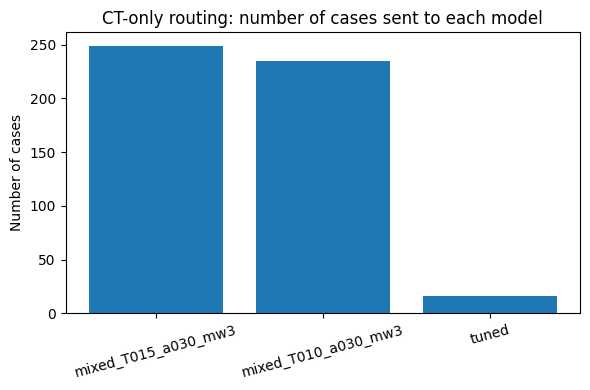

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_case_routing_analysis/ct2dose_case_routing_model_counts.png


In [22]:
route_count_df = routing_df["routed_model"].value_counts().reset_index()
route_count_df.columns = ["routed_model", "num_cases"]

route_count_csv = OUT_DIR / "ct2dose_case_routing_model_counts.csv"
route_count_df.to_csv(route_count_csv, index=False)

print("Saved:", route_count_csv)
display(route_count_df)

plt.figure(figsize=(6,4))
plt.bar(route_count_df["routed_model"], route_count_df["num_cases"])
plt.title("CT-only routing: number of cases sent to each model")
plt.ylabel("Number of cases")
plt.xticks(rotation=15)
plt.tight_layout()

route_count_png = OUT_DIR / "ct2dose_case_routing_model_counts.png"
plt.savefig(route_count_png, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", route_count_png)

### Cell 17 — Optional: scatter plot for intuition

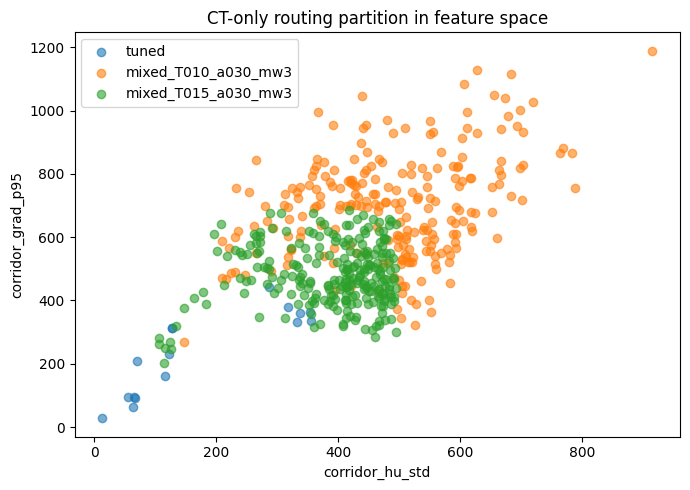

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_case_routing_analysis/ct2dose_case_routing_feature_scatter.png


In [23]:
plt.figure(figsize=(7,5))
for model_name in keep_models:
    sub = routing_df[routing_df["routed_model"] == model_name]
    plt.scatter(
        sub["corridor_hu_std"],
        sub["corridor_grad_p95"],
        alpha=0.6,
        label=model_name
    )

plt.xlabel("corridor_hu_std")
plt.ylabel("corridor_grad_p95")
plt.title("CT-only routing partition in feature space")
plt.legend()
plt.tight_layout()

scatter_png = OUT_DIR / "ct2dose_case_routing_feature_scatter.png"
plt.savefig(scatter_png, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", scatter_png)

### Cell 18 — Trello-ready compact table

In [24]:
trello_table = routed_vs_baselines_df.copy()

for col in trello_table.columns:
    if col != "model":
        trello_table[col] = trello_table[col].map(lambda x: f"{x:.6f}")

trello_csv = OUT_DIR / "ct2dose_case_routing_trello_summary.csv"
trello_table.to_csv(trello_csv, index=False)

print("Saved:", trello_csv)
display(trello_table)
print(trello_table.to_markdown(index=False))

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_case_routing_analysis/ct2dose_case_routing_trello_summary.csv


,model,overall_mae,weighted_mse,high_mae,outside_mae,outside_max_abs_error,peak_core_mae,peak_shoulder_mae
0,tuned,0.002662,0.000038,0.004830,0.002382,0.032495,0.047654,0.022622
1,mixed_T010_a030_mw3,0.002735,0.000036,0.004753,0.002484,0.034395,0.050831,0.020989
2,mixed_T015_a030_mw3,0.002737,0.000036,0.004922,0.002441,0.035028,0.047260,0.019714
3,ct_only_routed_system,0.002738,0.000037,0.004905,0.002457,0.034393,0.050254,0.020970


| model                 |   overall_mae |   weighted_mse |   high_mae |   outside_mae |   outside_max_abs_error |   peak_core_mae |   peak_shoulder_mae |
|:----------------------|--------------:|---------------:|-----------:|--------------:|------------------------:|----------------:|--------------------:|
| tuned                 |      0.002662 |        3.8e-05 |   0.00483  |      0.002382 |                0.032495 |        0.047654 |            0.022622 |
| mixed_T010_a030_mw3   |      0.002735 |        3.6e-05 |   0.004753 |      0.002484 |                0.034395 |        0.050831 |            0.020989 |
| mixed_T015_a030_mw3   |      0.002737 |        3.6e-05 |   0.004922 |      0.002441 |                0.035028 |        0.04726  |            0.019714 |
| ct_only_routed_system |      0.002738 |        3.7e-05 |   0.004905 |      0.002457 |                0.034393 |        0.050254 |            0.02097  |
